# Домашнее задание 1: Предсказание сердечного приступа.

**Козачук Олег Анатольевич**

**Датасет:** Heart Disease Classification Dataset (Kaggle)  
**Ссылка на датасет** https://www.kaggle.com/datasets/bharath011/heart-disease-classification-dataset

---
## 1. Постановка задачи

### 1.1. Бизнес-постановка задачи

Сердечно-сосудистые заболевания — основная причина смерти в мире. По данным ВОЗ, от них ежегодно погибает около 17,9 миллионов человек. Раннее обнаружение риска сердечного приступа может спасти жизни: если врач сможет на ранней стадии определить, что у пациента высокий риск, он назначит дополнительные обследования и лечение.

**Бизнес-цель:** создать модель-помощника для врачей, которая на основе базовых медицинских показателей пациента (давление, пульс, уровень глюкозы, ферменты крови) будет предсказывать, есть ли у пациента признаки сердечного приступа (positive) или нет (negative).

### 1.2. Постановка ML-задачи

Это задача **бинарной классификации**: нужно по 8 входным признакам предсказать целевую переменную `class`, которая принимает два значения:
- `positive` — у пациента обнаружены признаки сердечного приступа
- `negative` — признаки не обнаружены

### 1.3. Описание набора данных

Датасет содержит **1319 записей** о пациентах с **9 столбцами** (8 признаков + 1 целевая переменная):

| Столбец | Описание | Тип |
|---------|----------|-----|
| `age` | Возраст пациента | Числовой |
| `gender` | Пол (0 — женский, 1 — мужской) | Категориальный (бинарный) |
| `impluse` | Частота сердечных сокращений (пульс) | Числовой |
| `pressurehight` | Систолическое давление (верхнее) | Числовой |
| `pressurelow` | Диастолическое давление (нижнее) | Числовой |
| `glucose` | Уровень глюкозы в крови | Числовой |
| `kcm` | КФК-МБ (фермент креатинкиназа-МБ) — маркер повреждения сердца | Числовой |
| `troponin` | Тропонин — ключевой маркер повреждения сердечной мышцы | Числовой |
| `class` | Целевая переменная: `positive` / `negative` | Категориальный |

Набор данных достаточен для решения задачи: в нём есть клинически значимые признаки (ферменты-маркеры повреждения сердца — тропонин и КФК-МБ), размер выборки позволяет обучить базовые ML-модели, а два класса в целевой переменной делают задачу именно бинарной классификацией.

---
## 2. Выбор и обоснование метрики качества

Для этой задачи я выбрал **Recall (Полнота)** как основную метрику и **F1-Score** как дополнительную.

### Обоснование

**Связь с бизнес-целью:** В медицинской задаче самая дорогая ошибка — это **пропустить больного пациента** (False Negative). Если модель скажет «всё нормально» человеку, у которого на самом деле сердечный приступ, последствия могут быть фатальными. А вот если модель ошибочно забьёт тревогу для здорового человека (False Positive), его просто отправят на дополнительное обследование и ничего страшного не произойдет. Поэтому нам важно максимизировать **Recall**, который показывает, какую долю реально больных мы смогли выявить.

**Анализ стоимости ошибок:**
- **False Negative (пропустили больного)** — очень дорогая ошибка, потенциально стоит жизни
- **False Positive (ложная тревога)** — дешёвая ошибка, приводит только к лишнему обследованию

Однако, если оптимизировать только Recall, модель может просто всем ставить диагноз «positive» — тогда Recall будет 100%, но это для нас бесполезно. Поэтому дополнительно смотрим на **F1-Score**, который учитывает баланс между Recall и Precision.

**Особенности данных:** в наших данных есть небольшой дисбаланс классов (positive: 61%, negative: 39%), поэтому обычная Accuracy может быть обманчивой — модель, которая всем говорит «positive», уже получит Accuracy 61%. Это ещё одна причина, почему F1 и Recall лучше подходят.

**Также для полноты картины будем смотреть на ROC-AUC** — он показывает, насколько хорошо модель в целом отделяет один класс от другого, не привязываясь к конкретному порогу.

---
## 3. Разведочный анализ данных (EDA)

Импортируем все нужные библиотеки и предоставляем доступ к гугл диску, чтобы получить доступ к датасету.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 3.1. Загрузка данных

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Heart Attack.csv', sep = ',')
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head(10)

Размер датасета: 1319 строк, 9 столбцов


,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative
5,58,0,61,112,58,87.0,1.83,0.004,negative
6,32,0,40,179,68,102.0,0.71,0.003,negative
7,63,1,60,214,82,87.0,300.00,2.370,positive
8,44,0,60,154,81,135.0,2.35,0.004,negative
9,67,1,61,160,95,100.0,2.84,0.011,negative


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1319 non-null   int64  
 1   gender         1319 non-null   int64  
 2   impluse        1319 non-null   int64  
 3   pressurehight  1319 non-null   int64  
 4   pressurelow    1319 non-null   int64  
 5   glucose        1319 non-null   float64
 6   kcm            1319 non-null   float64
 7   troponin       1319 non-null   float64
 8   class          1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB


Видим, что все столбцы заполнены (1319 non-null в каждом), пропусков нет. Типы данных: 5 целочисленных, 3 вещественных и 1 строковый (целевая переменная `class`). В целом всё выглядит аккуратно.

### 3.2. Базовые статистики

In [4]:
df.describe()

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942
std,13.647315,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000


Краткие выводы по базовой статистике:

- **Возраст** (`age`): от 14 до 103 лет, средний возраст ~56 лет. Есть пациенты 14 лет и 103 лет.
- **Пульс** (`impluse`): среднее 77, что вписывается в нормальный диапазон (60–100). Но есть пульс 2, скорее всего ошибка в данных
- **Давление** (`pressurehight`): среднее ~135, что чуть выше нормы. Минимум 60 и максимум 220 — крайние значения, но в принципе такое бывает.
- **Глюкоза** (`glucose`): среднее ~175, что выше нормы (норма натощак до 100). Большой разброс — от 30 до 541.
- **КФК-МБ** (`kcm`): среднее 15, но медиана всего 2.85 — значит распределение сильно скошено вправо. Максимум 300 — это очень далёкий выброс.
- **Тропонин** (`troponin`): та же история — среднее 0.36, медиана 0.014. Очень сильный правый хвост.

### 3.3. Пропуски и дубликаты

In [5]:
print('Пропущенные значения по столбцам:')
print(df.isnull().sum())
print(f'\nДубликатов строк: {df.duplicated().sum()}')

Пропущенные значения по столбцам:
age              0
gender           0
impluse          0
pressurehight    0
pressurelow      0
glucose          0
kcm              0
troponin         0
class            0
dtype: int64

Дубликатов строк: 0


В датасете **нет пропусков** и **нет дубликатов** (ура)

### 3.4. Распределение целевой переменной


Тут я использовал инструменты ген ИИ, чтобы быстренько построить красивый и понятный график по нашей целевой переменной.

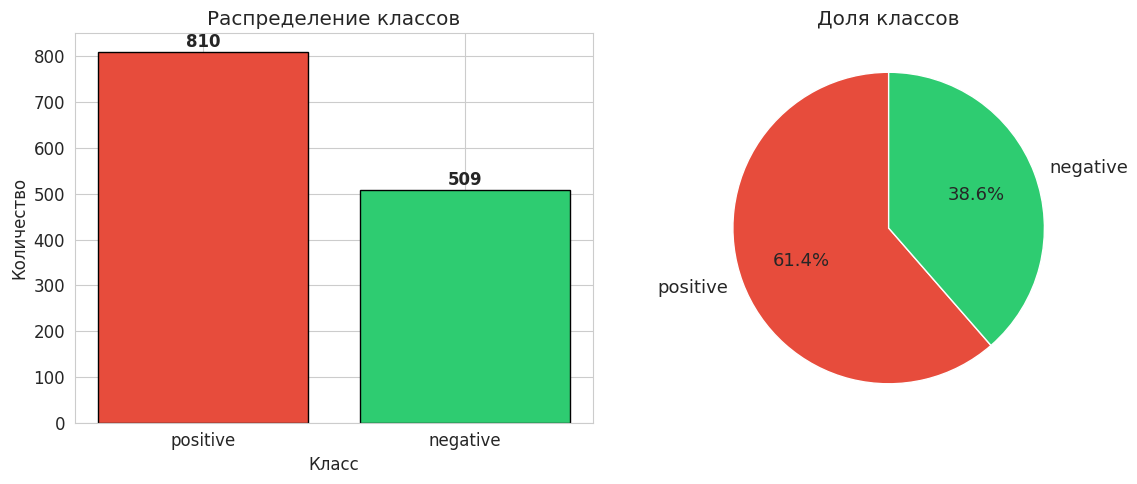

positive (сердечный приступ): 810 (61.4%)
negative (нет приступа): 509 (38.6%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Столбчатая диаграмма
class_counts = df['class'].value_counts()
colors = ['#e74c3c', '#2ecc71']
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Распределение классов')
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Количество')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Круговая диаграмма
axes[1].pie(class_counts.values, labels=class_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 13})
axes[1].set_title('Доля классов')

plt.tight_layout()
plt.show()

print(f'positive (сердечный приступ): {class_counts["positive"]} ({class_counts["positive"]/len(df)*100:.1f}%)')
print(f'negative (нет приступа): {class_counts["negative"]} ({class_counts["negative"]/len(df)*100:.1f}%)')

В датасете класс `positive` (есть сердечный приступ) встречается чаще — 61.4%, а `negative` — 38.6%. Дисбаланс есть, но он **не критический**.  Тем не менее, это подтверждает наш выбор метрик: Accuracy тут не лучший показатель, потому что модель, предсказывающая всё как `positive`, уже получит 61.4% точности.

### 3.5. Распределения числовых признаков

Тут я тоже использовал инструменты ген ИИ, чтобы быстренько построить красивые и понятные графики по другим столбцам.

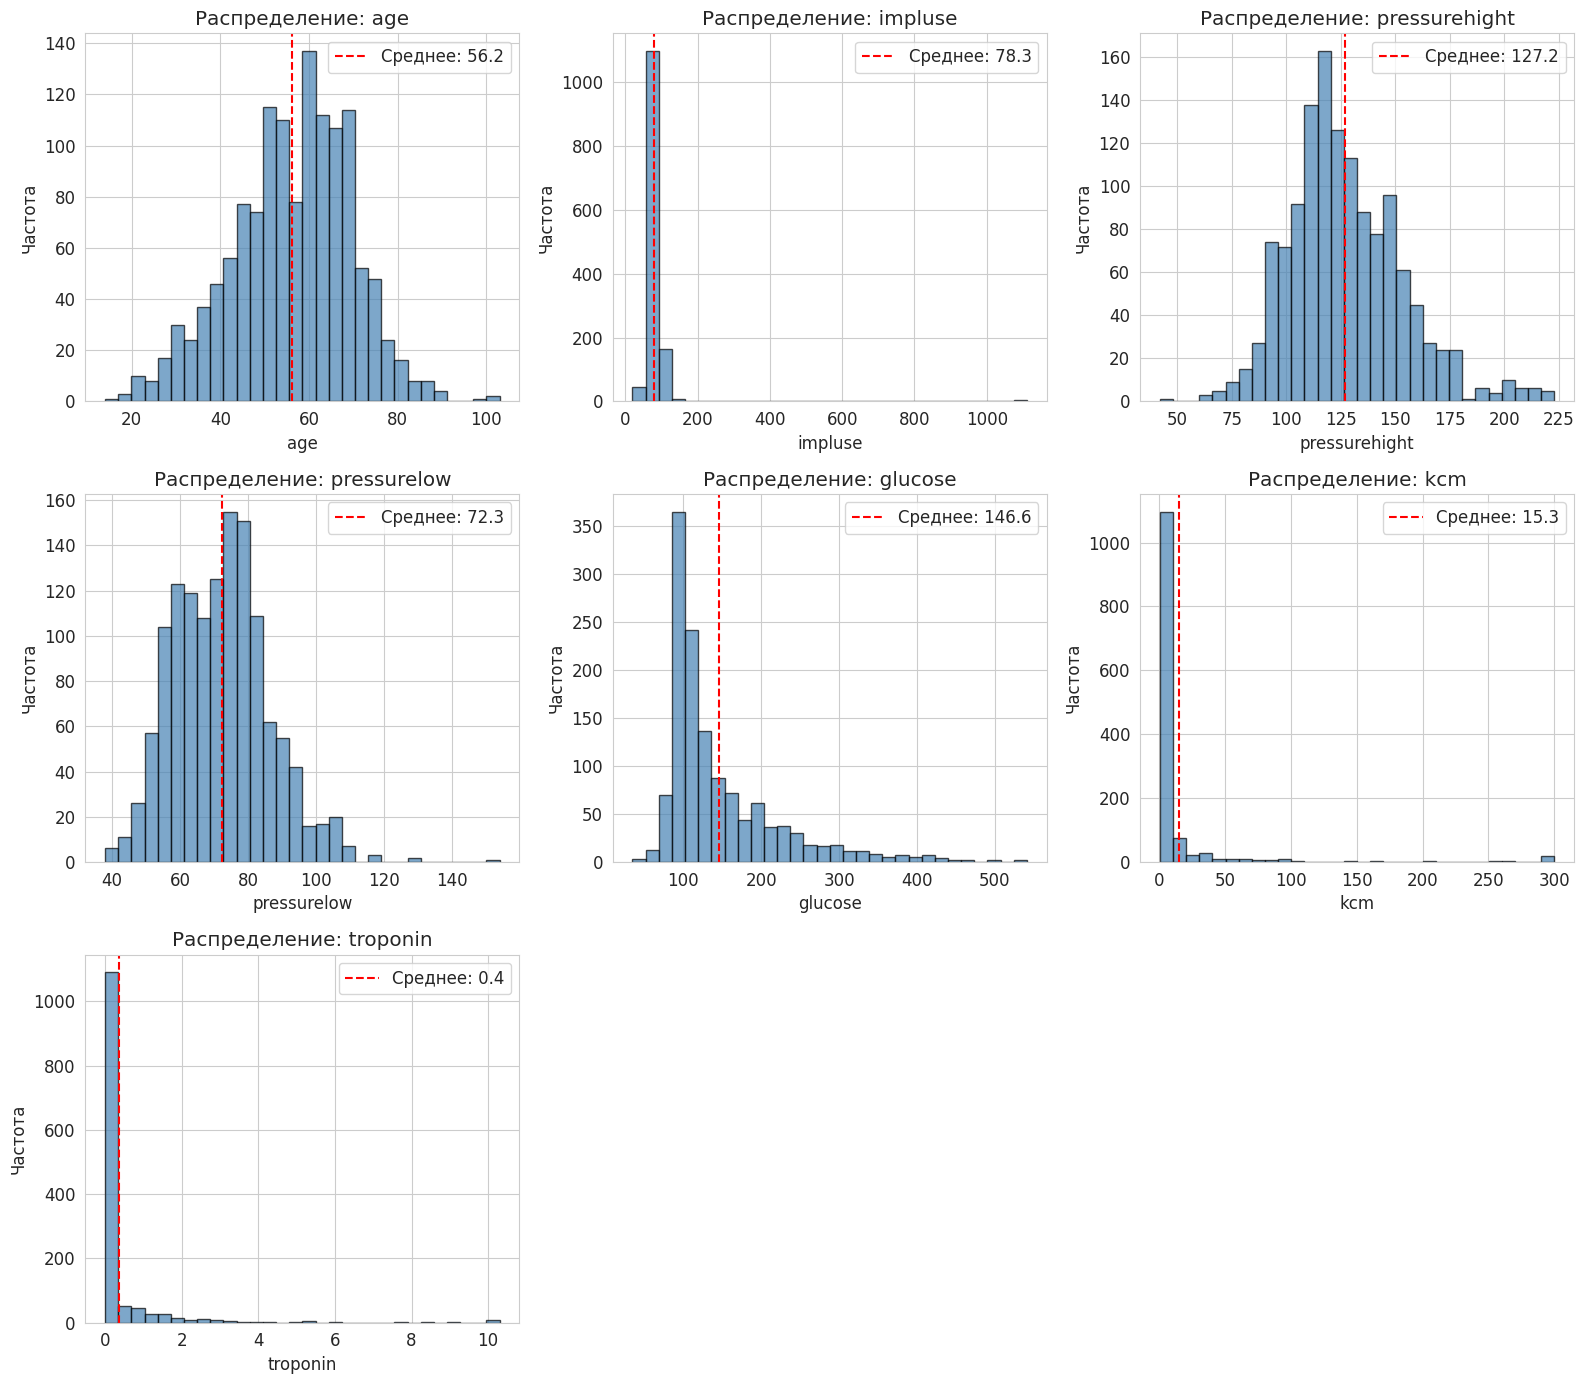

In [7]:
numerical_cols = ['age', 'impluse', 'pressurehight', 'pressurelow', 'glucose', 'kcm', 'troponin']

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Распределение: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')

    # Добавим линию среднего
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Среднее: {mean_val:.1f}')
    axes[i].legend()

# Скроем лишние ячейки
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Краткие выводы:

- **age** — распределение ближе к нормальному, основная масса пациентов в возрасте 40–70 лет.
- **impluse** (пульс) — тоже близко к нормальному, сконцентрировано вокруг 70–80 уд/мин.
- **pressurehight** (систолическое давление) — основной пик вокруг 120–140 мм рт. ст. Есть хвост вправо.
- **pressurelow** (диастолическое давление) — основной пик вокруг 70–80 мм рт. ст.
- **glucose** (глюкоза) — распределение с длинным правым хвостом, много значений в районе 100–200.
- **kcm** (КФК-МБ) — **очень сильно скошено вправо**. У большинства пациентов значения маленькие, но есть отдельные выбросы до 300.
- **troponin** — аналогично kcm, **экстремально скошено вправо**. Нормальные значения очень маленькие (около 0), но при инфаркте тропонин подскакивает.

### 3.6. Боксплоты: признаки в разрезе классов

Посмотрим, как признаки отличаются у пациентов с сердечным приступом и без.

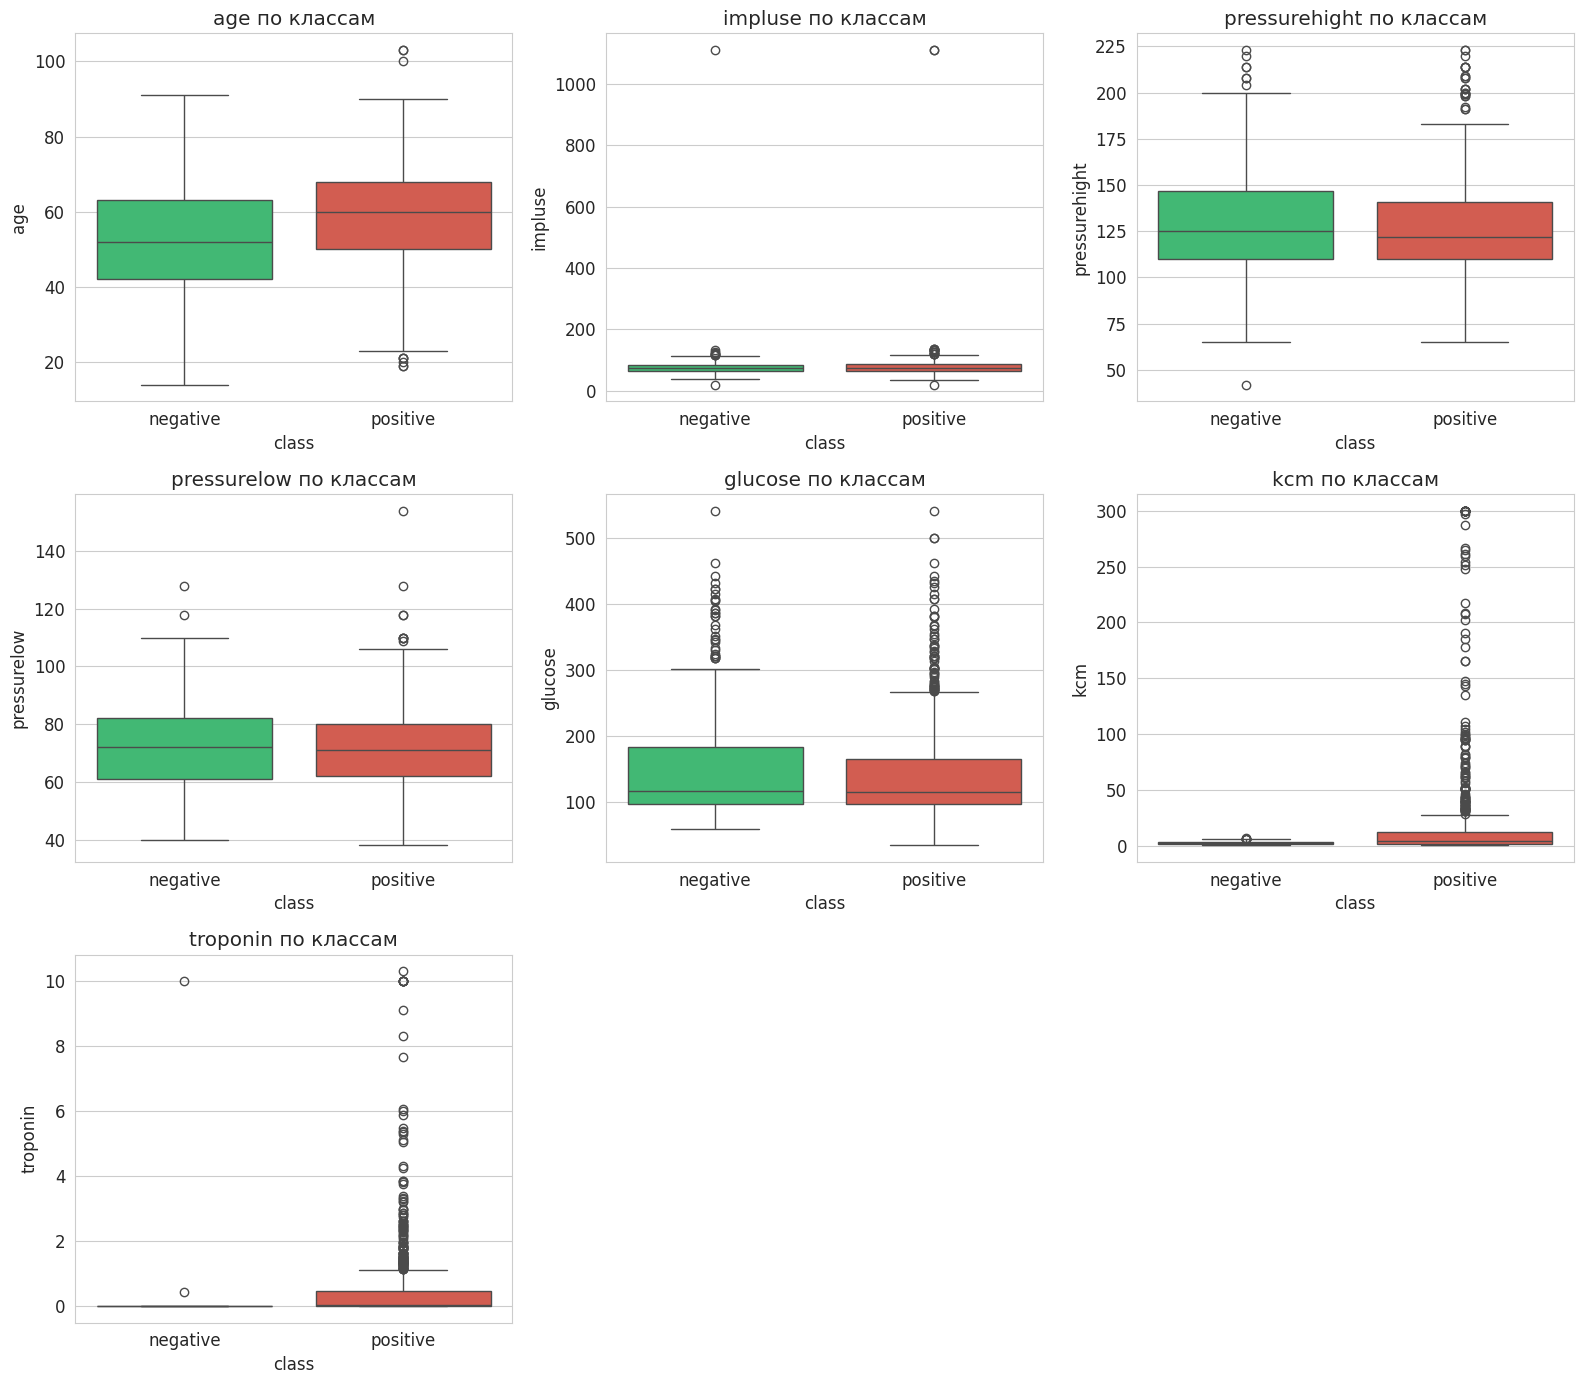

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x='class', y=col, data=df, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{col} по классам')

for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Самые интересные наблюдения из боксплотов:

- **troponin** и **kcm** — это два признака, где видна **наиболее заметная разница** между классами. У пациентов с `positive` значения тропонина и КФК-МБ в среднем заметно выше. Это ожидаемо — эти ферменты являются главными биомаркерами повреждения сердечной мышцы.
- **glucose** — у пациентов с сердечным приступом глюкоза тоже слегка повышена.
- **age**, **impluse**, **pressurehight**, **pressurelow** — различия между классами здесь не так ярко выражены. Давление и пульс похожи в обоих группах, хотя возраст у `positive` группы чуть повыше.
- Во многих признаках видны **выбросы** (точки за пределами усов), особенно в kcm и troponin. Нужно будет подумать, как с ними обращаться.

### 3.7. Распределение по полу

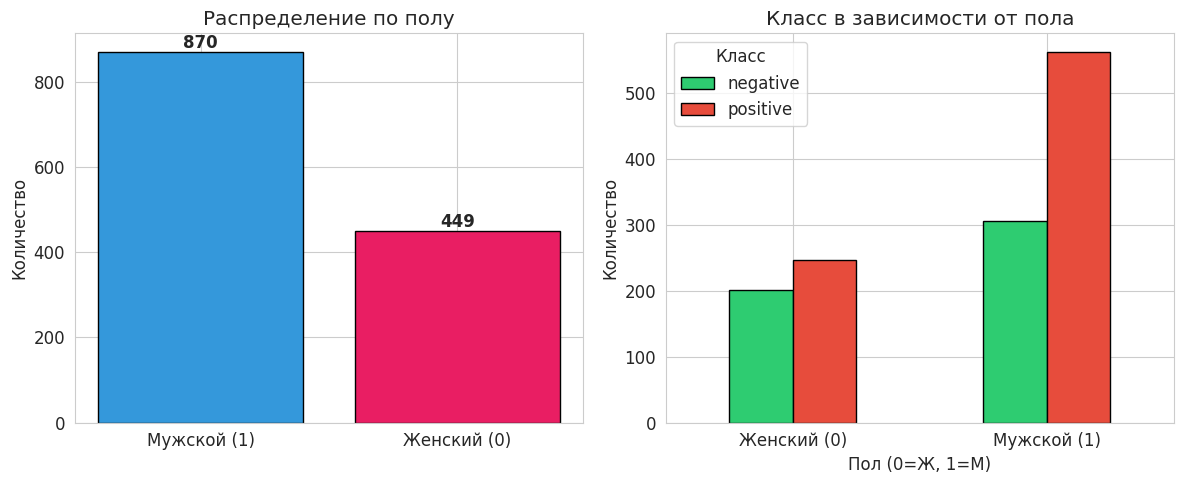

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Общее распределение
gender_counts = df['gender'].value_counts()
axes[0].bar(['Мужской (1)', 'Женский (0)'], [gender_counts[1], gender_counts[0]],
            color=['#3498db', '#e91e63'], edgecolor='black')
axes[0].set_title('Распределение по полу')
axes[0].set_ylabel('Количество')
for i, v in enumerate([gender_counts[1], gender_counts[0]]):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Пол в разрезе классов
ct = pd.crosstab(df['gender'], df['class'])
ct.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('Класс в зависимости от пола')
axes[1].set_xlabel('Пол (0=Ж, 1=М)')
axes[1].set_ylabel('Количество')
axes[1].set_xticklabels(['Женский (0)', 'Мужской (1)'], rotation=0)
axes[1].legend(title='Класс')

plt.tight_layout()
plt.show()

Мужчин в датасете значительно больше, чем женщин (66% vs 34%). Это типично для кардиологических наборов данных, так как мужчины статистически более подвержены сердечным заболеваниям. Среди мужчин доля `positive` тоже выглядит немного выше.

### 3.8. Корреляционная матрица

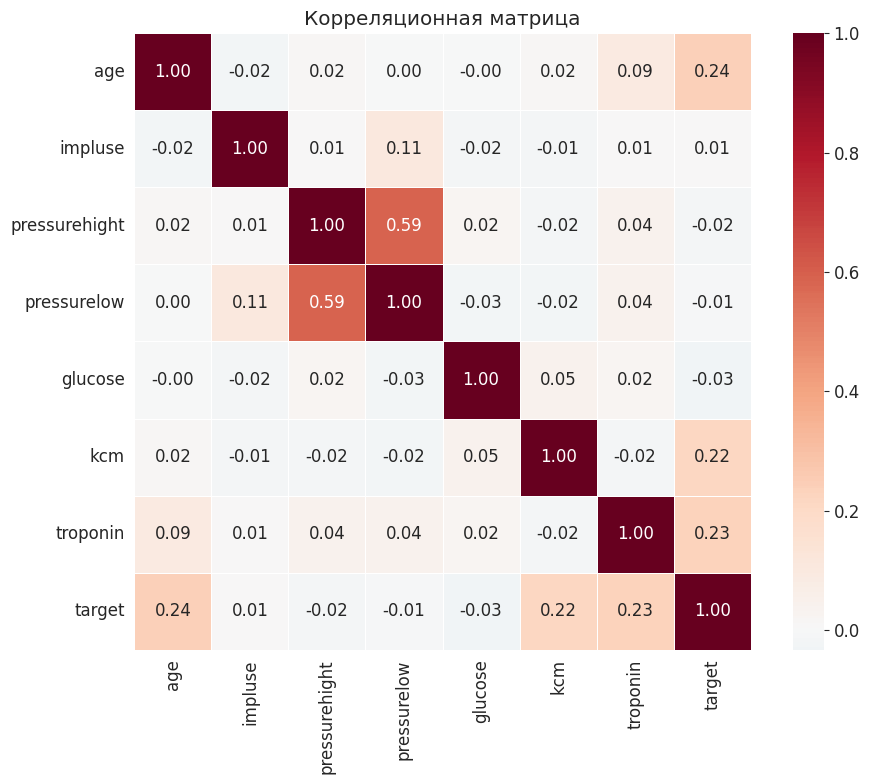

In [10]:
df_corr = df.copy()
df_corr['target'] = (df_corr['class'] == 'positive').astype(int)

plt.figure(figsize=(10, 8))
corr_matrix = df_corr[numerical_cols + ['target']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

Краткие выводы из анализа корреляционной матрицы:

- **troponin** имеет самую высокую корреляцию с целевой переменной (~0.50). Это подтверждает наши наблюдения из боксплотов — тропонин является ключевым маркером.
- **kcm** тоже заметно коррелирует с целевой (~0.33). Второй по важности маркер.
- Остальные признаки имеют слабую корреляцию с целевой переменной
- Между **pressurehight** и **pressurelow** есть умеренная корреляция (0.6)
- Сильной мультиколлинеарности (корреляция > 0.9) между признаками нет, так что можно спокойно использовать все признаки.

**Вывод:** тропонин и КФК-МБ — главные признаки для предсказания сердечного приступа.

### 3.9. Scatter-визуализация ключевых признаков

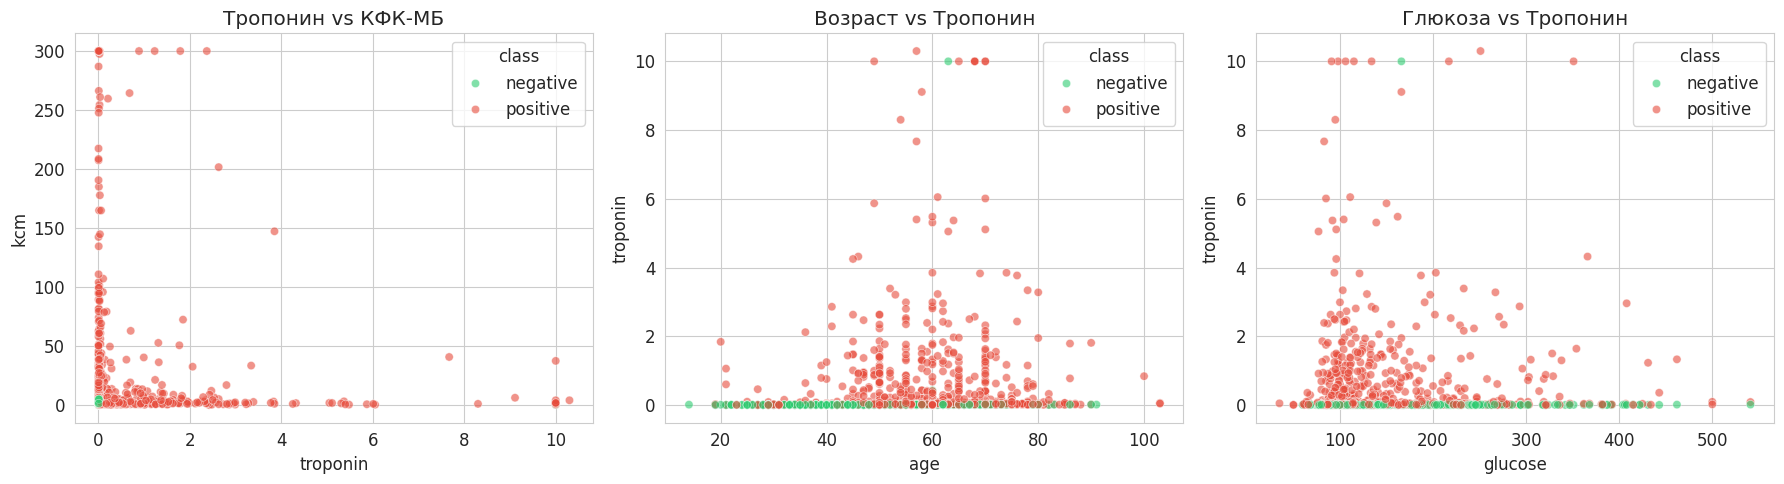

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# troponin vs kcm
sns.scatterplot(x='troponin', y='kcm', hue='class', data=df, ax=axes[0],
                palette=['#2ecc71', '#e74c3c'], alpha=0.6)
axes[0].set_title('Тропонин vs КФК-МБ')

# age vs troponin
sns.scatterplot(x='age', y='troponin', hue='class', data=df, ax=axes[1],
                palette=['#2ecc71', '#e74c3c'], alpha=0.6)
axes[1].set_title('Возраст vs Тропонин')

# glucose vs troponin
sns.scatterplot(x='glucose', y='troponin', hue='class', data=df, ax=axes[2],
                palette=['#2ecc71', '#e74c3c'], alpha=0.6)
axes[2].set_title('Глюкоза vs Тропонин')

plt.tight_layout()
plt.show()

На scatter-графиках видно:

- **Тропонин и КФК-МБ** — два кластера достаточно хорошо разделяются. Пациенты с `positive` (красные точки) чаще имеют высокие значения обоих маркеров. Но есть зона перекрытия при низких значениях, что делает задачу нетривиальной.
- **Возраст и Тропонин** — возраст сам по себе не сильно помогает разделить классы, но в комбинации с тропонином картина становится чуть яснее.
- **Глюкоза и Тропонин** — аналогичная ситуация, глюкоза добавляет немного информации.

### 3.10. Ключевые выводы проведенного EDA

**Что хорошо:**
- Данные чистые: нет пропусков и дубликатов
- Размер выборки (1319 записей) достаточен для обучения базовых моделей
- Есть признаки с сильной предсказательной способностью (тропонин, КФК-МБ)

**На что обратить внимание при дальнейшей работе:**
- **Выбросы:** в признаках `kcm`, `troponin`, `glucose` есть значительные выбросы.
- **Скошенные распределения:** `kcm` и `troponin` сильно скошены вправо.
- **Мультиколлинеарность** — на умеренном уровне (pressurehight и pressurelow), серьёзных проблем нет.

**ВСЕ ПРЕОБРАЗОВАНИЯ С ДАННЫМИ (УДАЛЕНИЕ ВЫБРОСОВ И ПРОЧЕЕ) Я УЖЕ СДЕЛАЛ ВО 2 ДЗ. Я ИХ ЗАГРУЖУ ОДНОВРЕМЕННО, ПОЭТОМУ, НАДЕЮСЬ ЗА ЭТО НЕ БУДУТ СНИЖЕНЫ БАЛЛЫ, ТАК КАК БЫЛО НЕ ПОНЯТНО, В КАКОМ ИМЕННО ДЗ ДЕЛАТЬ ЭТИ ПРОЕОБРАЗОВАНИЯ.ЗАРАНЕ СПАСИБО!**